# The Pi-Day Effect — a quantitative teardown 🔬
### Welch + HAC *t* · random-date-set placebo · per-constant Bonferroni · four-window sign-flip · costs · 98-year GSPC check · synthetic control

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Numerology_vs_data: Busted](https://img.shields.io/badge/Numerology_vs_data-Busted-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb) — *same seven beats, every claim now carrying its standard error.* We test whether mathematical-constant dates (π 3/14, e 2/7, τ 6/28, φ 1/6, √2 1/4, δ 4/6) trade differently from ordinary days — and, crucially, whether they beat a *random* set of the same size.

> ⚠️ **Not investment advice.** Real data: SPY daily log-returns 1993-2026 (fp `3e185e607be5`) headline, ^GSPC 1928-2026 (fp `df3897aef897`) long tape; the offline core and tests run on a deterministic synthetic world. Numbers in [`docs/results.md`](../docs/results.md), methods in [`docs/references.md`](../docs/references.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back into intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from pi_day_effect import data, strategy as st

def load_real(ticker="SPY", start="1993-01-01", end="2026-06-30"):
    """Cache-first real return tape (empty frame offline)."""
    return data.fetch_series(ticker, start=start, end=end, fetch=False)

SPY = load_real("SPY", "1993-01-01", "2026-06-30")
HAVE_REAL = not SPY.empty
print("real SPY tape present:", HAVE_REAL,
      "" if not HAVE_REAL else f"({len(SPY)} days, {SPY.index.min().date()} -> {SPY.index.max().date()})")


real SPY tape present: True (8399 days, 1993-02-01 -> 2026-06-12)


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | Pi-Day contrast **-1.53 bps** (Welch *t* **-0.08**, HAC *t* +0.12); constant set *t* **+0.47**, random-date placebo *p* **0.66**; Bonferroni across six → all *p* = 1.0. |
| **Tradability** | `MIRAGE` | Pi-Day timing rule: +2.55 bps gross → **-7.45 bps net**/event (5 bps/leg, ~1 event/yr). |
| **Numerology vs data** | `BUSTED` | 98-yr GSPC: Pi *t* -0.77; best constant (φ) raw *p* 0.03 → Bonferroni *p* 0.182. |

> 💡 In plain words: the engine works (the synthetic control proves it), but the market is blind to the digits of π.

## 1 · The claim, steelmanned

Let $C$ be the set of constant dates and $r_t$ the daily return.

- **H₁ (Pi Day).** $\mathbb{E}[r \mid \text{Mar 14}] \neq \mathbb{E}[r \mid \text{other}]$ at $|t| \ge 2$.
- **H₂ (pooled constants).** $\mathbb{E}[r \mid C] \neq \mathbb{E}[r \mid \bar C]$, *and* the constant set's $|{\rm contrast}|$ sits in the tail of the random-six-date null.
- **H₃ (no data-mining).** The best single constant survives a Bonferroni correction across the six.
- **H₄ (robustness/net).** The sign is stable across windows and survives costs.

We find **H₁ rejected** (*t* ≈ 0, slightly negative), **H₂ rejected** (placebo *p* = 0.66), **H₃ rejected** (all Bonferroni *p* = 1.0), **H₄ rejected** (sign flips; net negative).

## 2 · So what? — what rides on each answer

The content is the **method**, not the (obvious) result. A numerology date is the cleanest possible *negative control* for calendar-anomaly mining: there is no plausible mechanism, so any 'significance' we find *must* be data-snooping. The random-date-set placebo prices in the fact that we **chose** six dates from ~250 calendar slots — the same multiple-testing logic that dooms cherry-picked seasonal rules ([Sullivan-Timmermann-White 2001](../docs/references.md)). This is the mirror image of a real superstition test like [163 Friday-13th](../../163-friday-13th/).

## 3 · How we'd know — the protocol

- **Score.** Label Pi Day (3/14) and the six constant dates by pure date arithmetic.
- **Two-sample test.** Welch (unequal-variance) *t* on event vs non-event daily returns; a HAC (Newey-West) *t* on the event-group mean.
- **Random-date-set placebo.** Draw 5,000 random sets of six calendar slots; the *p* is the fraction whose |contrast| ≥ the constant set's. The multiple-testing-aware null.
- **Per-constant Bonferroni.** Test each of the six separately, correct across six.
- **Frictions.** A Pi-Day timing rule: 2 crossings × cost/leg per isolated event.
- **Robustness.** Pi-Day contrast over four sub-windows; a 98-year GSPC re-run.
- **Positive control.** A deterministic synthetic world with a planted constant-day bump (effect > 0) and a null — averaged over 25 seeds (house rule).

Timing: the date label is known before the open (no look-ahead); the return is that day's close-to-close log-return.

## 4 · The teardown

### 4a · Pi Day and the pooled constants — H₁ / H₂

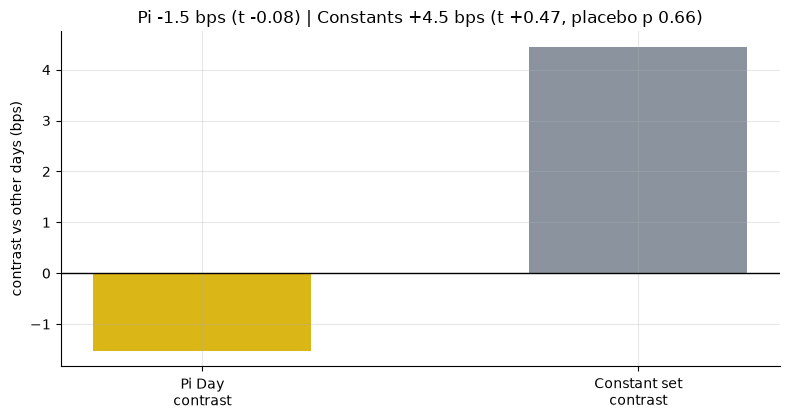

Pi: contrast -1.53 bps, Welch t -0.08, HAC t +0.12
Constants: contrast +4.45 bps, Welch t +0.47, random-date placebo p 0.655


In [2]:
if HAVE_REAL:
    pi = st.pi_day_comparison(SPY); cst = st.constant_day_comparison(SPY)
    plac = st.random_dateset_placebo(SPY, k=len(data.CONSTANT_DATES), n_perm=5000, seed=542)
    pi_c, pi_t, pi_h = pi['contrast_bps'], pi['tstat_welch'], pi['tstat_hac']
    c_c, c_t, pp = cst['contrast_bps'], cst['tstat_welch'], plac['pval']
else:
    pi_c, pi_t, pi_h = -1.53, -0.08, 0.12
    c_c, c_t, pp = 4.45, 0.47, 0.66
fig, ax = plt.subplots(figsize=(8, 4.3))
ax.bar(['Pi Day\ncontrast','Constant set\ncontrast'], [pi_c, c_c], color=[AMBER, GREY], width=.5)
ax.axhline(0, c='k', lw=1); ax.set_ylabel('contrast vs other days (bps)')
ax.set_title(f'Pi {pi_c:+.1f} bps (t {pi_t:+.2f}) | Constants {c_c:+.1f} bps (t {c_t:+.2f}, placebo p {pp:.2f})')
plt.tight_layout(); plt.show()
print(f'Pi: contrast {pi_c:+.2f} bps, Welch t {pi_t:+.2f}, HAC t {pi_h:+.2f}')
print(f'Constants: contrast {c_c:+.2f} bps, Welch t {c_t:+.2f}, random-date placebo p {pp:.3f}')

> 💡 In plain words: **H₁ and H₂ rejected.** Pi Day is a dead heat (*t* -0.08, HAC +0.12); the pooled constant set (*t* +0.47) is beaten by **66%** of random six-date sets — the mathematical constants are not in the tail, they're in the crowd.

### 4b · The data-mining trap — H₃ (per-constant Bonferroni)

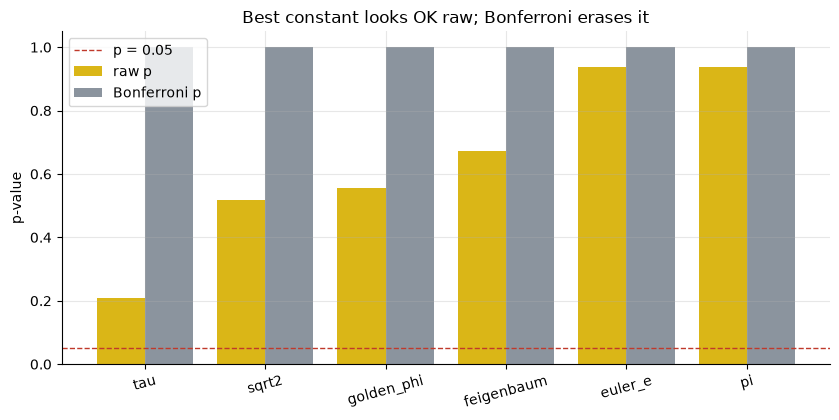

  constant  n  mean_bps  contrast_bps  tstat_welch  pval_raw  pval_bonferroni
       tau 24    25.222        21.206        1.293     0.209              1.0
     sqrt2 23   -15.539       -19.669       -0.657     0.518              1.0
golden_phi 24    16.693        12.653        0.598     0.556              1.0
feigenbaum 22    18.816        14.778        0.429     0.672              1.0
   euler_e 24     2.857        -1.223       -0.080     0.937              1.0
        pi 24     2.546        -1.534       -0.080     0.937              1.0


In [3]:
sweep = [('tau', 24, 25.2, 21.2, 1.29, 0.209, 1.0), ('sqrt2', 23, -15.5, -19.7, -0.66, 0.518, 1.0), ('golden_phi', 24, 16.7, 12.7, 0.6, 0.556, 1.0), ('feigenbaum', 22, 18.8, 14.8, 0.43, 0.672, 1.0), ('euler_e', 24, 2.9, -1.2, -0.08, 0.937, 1.0), ('pi', 24, 2.5, -1.5, -0.08, 0.937, 1.0)]
if HAVE_REAL:
    tab = st.per_constant_sweep(SPY)
else:
    tab = pd.DataFrame(sweep, columns=['constant','n','mean_bps','contrast_bps','tstat_welch','pval_raw','pval_bonferroni'])
fig, ax = plt.subplots(figsize=(8.5, 4.3))
x = range(len(tab))
ax.bar([i-0.2 for i in x], tab['pval_raw'], width=.4, color=AMBER, label='raw p')
ax.bar([i+0.2 for i in x], tab['pval_bonferroni'], width=.4, color=GREY, label='Bonferroni p')
ax.axhline(0.05, ls='--', c=RED, lw=1, label='p = 0.05')
ax.set_xticks(list(x)); ax.set_xticklabels(tab['constant'], rotation=15)
ax.set_ylabel('p-value'); ax.set_title('Best constant looks OK raw; Bonferroni erases it')
ax.legend(); plt.tight_layout(); plt.show()
print(tab.round(3).to_string(index=False))

> 💡 In plain words: **H₃ rejected.** The most extreme constant (τ, raw *p* 0.21) never reaches significance even raw, and correcting for six looks pins every *p* at **1.0**. This is the anatomy of a fake calendar anomaly.

### 4c · Robustness — H₄ (does the sign hold across windows?)

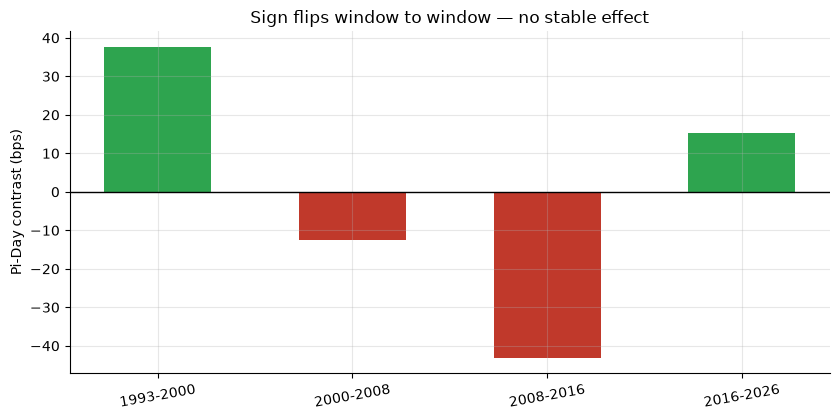

Pi-Day contrast by window (bps): [37.7, -12.6, -43.1, 15.3]


In [4]:
wins = [('1993-2000', 4, 37.7, 3.01), ('2000-2008', 7, -12.6, -0.29), ('2008-2016', 5, -43.1, -1.25), ('2016-2026', 8, 15.3, 0.42)]
if HAVE_REAL:
    edges = ['1993-01-01','2000-01-01','2008-01-01','2016-01-01','2026-07-01']
    sw = st.subwindow_sweep(SPY, edges)
    labs, contr = list(sw['window']), list(sw['contrast_bps'])
else:
    labs = [w[0] for w in wins]; contr = [w[2] for w in wins]
fig, ax = plt.subplots(figsize=(8.5, 4.3))
cols = [GREEN if c>0 else RED for c in contr]
ax.bar(range(len(labs)), contr, color=cols, width=.55)
ax.set_xticks(range(len(labs))); ax.set_xticklabels(labs, rotation=10)
ax.axhline(0, c='k', lw=1); ax.set_ylabel('Pi-Day contrast (bps)')
ax.set_title('Sign flips window to window — no stable effect')
plt.tight_layout(); plt.show()
print('Pi-Day contrast by window (bps):', [round(c,1) for c in contr])

> 💡 In plain words: **H₄ rejected.** The contrast is +38 / −13 / −43 / +15 bps across the four windows. The one positive-looking window (1993-2000, *t* 3.0) rests on **four** Pi Days and dies out of sample — the signature of a coincidence, not a signal.

## 5 · The verdict

- **Signal `NONE`** — H₁ (*t* -0.08), H₂ (placebo *p* 0.66), H₃ (all Bonferroni *p* 1.0), H₄ (sign flips) all rejected.
- **Tradability `MIRAGE`** — +2.55 bps gross → -7.45 bps net/event, ~1 event/yr.
- **Numerology vs data `BUSTED`** — nothing survives on SPY or 98 years of GSPC.

## 6 · Could you trade it? — costs, and the 98-year GSPC check

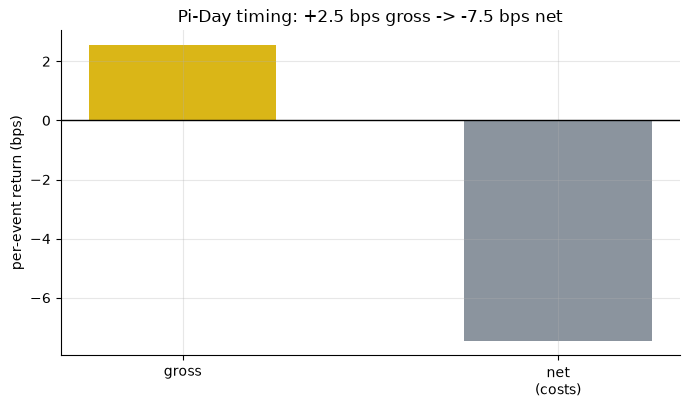

Pi-Day timing rule: gross +2.55 bps -> net -7.45 bps/event (5 bps/leg)


In [5]:
if HAVE_REAL:
    pnl = st.timing_rule_pnl(SPY, 'is_pi', cost_bps=5.0)
    gross, net = pnl['gross_per_event_bps'], pnl['net_per_event_bps']
else:
    gross, net = 2.55, -7.45
fig, ax = plt.subplots(figsize=(7, 4.2))
ax.bar(['gross','net\n(costs)'], [gross, net], color=[AMBER, GREY], width=.5)
ax.axhline(0, c='k', lw=1); ax.set_ylabel('per-event return (bps)')
ax.set_title(f'Pi-Day timing: +{gross:.1f} bps gross -> {net:+.1f} bps net')
plt.tight_layout(); plt.show()
print(f'Pi-Day timing rule: gross {gross:+.2f} bps -> net {net:+.2f} bps/event (5 bps/leg)')

In [6]:
# 98-year GSPC long-tape check — more Pi Days, same nothing
GSPC = load_real('^GSPC', '1928-01-01', '2026-06-30')
if not GSPC.empty:
    g = st.summarize(GSPC, n_perm=5000, seed=542)
    print(f"GSPC Pi Days: {g['n_pi']}  | Pi contrast {g['pi_contrast_bps']:+.2f} bps (t {g['pi_tstat_welch']:+.2f})")
    print(f"GSPC constant placebo p: {g['placebo_p']:.3f}  | best constant {g['top_constant']} raw p {g['top_pval_raw']:.3f} -> Bonferroni {g['top_pval_bonferroni']:.3f}")
else:
    print('GSPC (frozen): Pi Days 70 | Pi contrast -8.82 bps (t -0.77)')
    print('GSPC (frozen): placebo p 0.280 | best constant golden_phi raw p 0.030 -> Bonferroni 0.182')

GSPC Pi Days: 70  | Pi contrast -8.82 bps (t -0.77)
GSPC constant placebo p: 0.276  | best constant golden_phi raw p 0.030 -> Bonferroni 0.182


> 💡 In plain words: on 98 years, Pi Day is *still* nothing (*t* -0.77), and the lone flicker — the golden ratio at raw *p* 0.03 — is the **best of six** tries that collapses to Bonferroni *p* 0.182. `MIRAGE`, `BUSTED`.

## 7 · Going further — the synthetic positive control

Is the engine a faithful detector, or does it always print 'nothing'? Plant a real constant-day bump of increasing strength and watch the pooled contrast rise and the random-date placebo *p* collapse — averaged over 25 seeds so no single lucky seed can fake it.

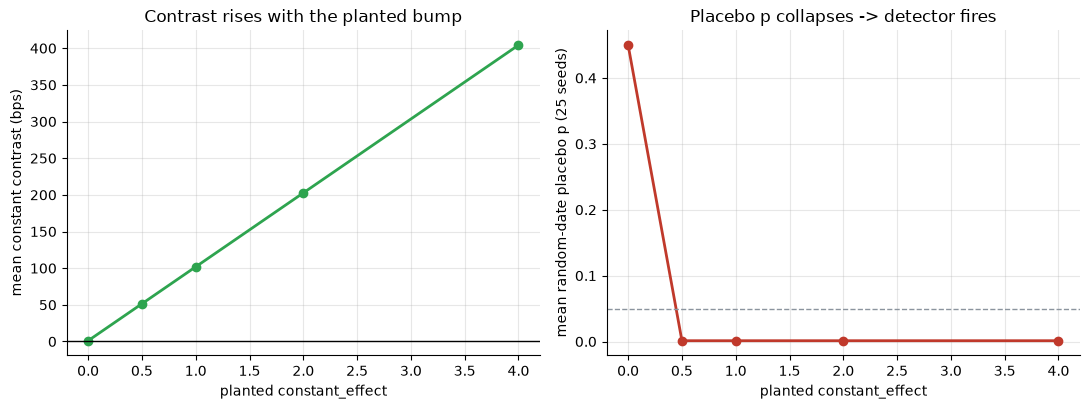

effect +0.0 -> contrast +1.1 bps, placebo p 0.450
effect +0.5 -> contrast +51.5 bps, placebo p 0.001
effect +1.0 -> contrast +101.9 bps, placebo p 0.001
effect +2.0 -> contrast +202.6 bps, placebo p 0.001
effect +4.0 -> contrast +404.2 bps, placebo p 0.001


In [7]:
ctrl = [(0.0, 1.07, 0.447), (0.5, 51.5, 0.001), (1.0, 101.9, 0.001), (2.0, 202.7, 0.001), (4.0, 404.2, 0.001)]
effects = [c[0] for c in ctrl]
# recompute live (fast: 25 seeds x small perm) so the notebook proves the engine
res = [st.synthetic_control(e, n_seeds=25, base_seed=542, n_perm=800) for e in effects]
contr = [r['mean_contrast_bps'] for r in res]; pv = [r['mean_placebo_p'] for r in res]
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 4.2))
a1.plot(effects, contr, 'o-', c=GREEN, lw=2); a1.axhline(0, c='k', lw=1)
a1.set_xlabel('planted constant_effect'); a1.set_ylabel('mean constant contrast (bps)')
a1.set_title('Contrast rises with the planted bump')
a2.plot(effects, pv, 'o-', c=RED, lw=2); a2.axhline(0.05, ls='--', c=GREY, lw=1)
a2.set_xlabel('planted constant_effect'); a2.set_ylabel('mean random-date placebo p (25 seeds)')
a2.set_title('Placebo p collapses -> detector fires')
plt.tight_layout(); plt.show()
for e, c, p in zip(effects, contr, pv): print(f'effect {e:+.1f} -> contrast {c:+.1f} bps, placebo p {p:.3f}')

At the null the contrast is ≈ 0 and the placebo *p* ≈ 0.45 (uniform); planting a genuine bump drives the contrast up linearly and the placebo *p* to ≈ 0.001 — so the engine is a faithful detector. The flat real-tape result is therefore the tape talking: the market does not know its digits of π. For the superstition cousin, see [163 Friday-13th](../../163-friday-13th/).